# Using the DBSCAN implementation from scikit-learn

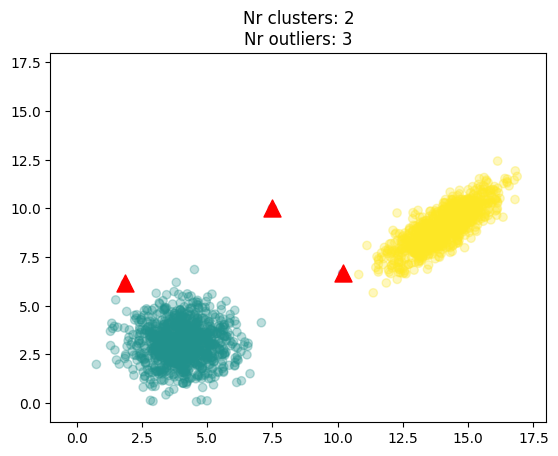

In [1]:
import numpy as np

np.random.seed(42)

import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

mean1 = [4,3]
cov1 = [[1,0],
        [0,1]]

mean2 = [14,9]
cov2 = [[1,0.8],
        [0.8,1]]

p1 = np.random.multivariate_normal(mean1, cov1, size=1000)
p2 = np.random.multivariate_normal(mean2, cov2, size=1000)
p3 = np.array( [7.5, 10.0] )

p = np.vstack( [p1,p2,p3] )

clusterer = DBSCAN(eps=1, min_samples=10,).fit(p)
nr_clusters_found = max(clusterer.labels_) + 1
nr_outliers_found = np.sum(clusterer.labels_ == -1)
outliers = p[clusterer.labels_ == -1]

plt.scatter(p[:,0], p[:,1], alpha=0.3, c=clusterer.labels_)
plt.scatter(outliers[:,0], outliers[:,1], color="red", marker="^", s=150)
plt.xlim(-1,18)
plt.ylim(-1,18)
plt.title(f"Nr clusters: {nr_clusters_found}\n" + \
          f"Nr outliers: {nr_outliers_found}" )
plt.show()

In [2]:
p

array([[ 4.49671415,  2.8617357 ],
       [ 4.64768854,  4.52302986],
       [ 3.76584663,  2.76586304],
       ...,
       [16.07247243, 10.86989831],
       [12.32690771,  7.55500147],
       [ 7.5       , 10.        ]], shape=(2001, 2))

In [3]:
p1.shape

(1000, 2)

In [4]:
p2.shape

(1000, 2)

In [5]:
p.shape

(2001, 2)

In [6]:
clusterer.labels_

array([ 0,  0,  0, ...,  1,  1, -1], shape=(2001,))

In [7]:
len(clusterer.labels_)

2001

In [8]:
min(clusterer.labels_)

np.int64(-1)

In [9]:
clusterer.labels_[:500]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

# Determining the nr of noise points / outliers

In [10]:
clusterer.labels_ == -1

array([False, False, False, ..., False, False,  True], shape=(2001,))

In [11]:
(clusterer.labels_ == -1).dtype

dtype('bool')

In [12]:
(clusterer.labels_ == -1).astype(int)

array([0, 0, 0, ..., 0, 0, 1], shape=(2001,))

In [13]:
(clusterer.labels_ == -1).astype(int).sum()

np.int64(3)

In [14]:
np.sum(clusterer.labels_ == -1)

np.int64(3)

In [15]:
(clusterer.labels_ == -1).sum()

np.int64(3)

In [16]:
p

array([[ 4.49671415,  2.8617357 ],
       [ 4.64768854,  4.52302986],
       [ 3.76584663,  2.76586304],
       ...,
       [16.07247243, 10.86989831],
       [12.32690771,  7.55500147],
       [ 7.5       , 10.        ]], shape=(2001, 2))

In [17]:
nr_inliers = np.sum(clusterer.labels_ != -1)
nr_inliers

np.int64(1998)

In [18]:
inliers = p[clusterer.labels_ != -1]
inliers

array([[ 4.49671415,  2.8617357 ],
       [ 4.64768854,  4.52302986],
       [ 3.76584663,  2.76586304],
       ...,
       [15.95011072, 10.96810887],
       [16.07247243, 10.86989831],
       [12.32690771,  7.55500147]], shape=(1998, 2))

In [19]:
inliers.shape

(1998, 2)